# DB1B Data Validation — Airline Merger Project
**STAT 418 Final Project**

This notebook downloads one quarter of DOT Bureau of Transportation Statistics DB1B Market data and validates it for the American Airlines / US Airways merger analysis.

**Merger details:**
- American Airlines and US Airways merged in **December 2013**
- Pre-period: 2010–2013 | Post-period: 2014–2017
- Treated routes: those where **both AA and US** flew pre-merger
- Control routes: those where only **one** of the two flew pre-merger

---
### Setup — install dependencies if needed
```bash
pip install requests pandas pyarrow matplotlib seaborn
```

In [2]:
import requests
import zipfile
import io
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('All imports successful ✅')

All imports successful ✅


---
## 1. Download One Quarter of DB1B Market Data

We pull **2013 Q1** — one of the last quarters before the merger closed in December 2013.

The BTS bulk download URL pattern is:
```
https://transtats.bts.gov/PREZIP/Origin_and_Destination_Survey_DB1BMarket_{year}_{quarter}.zip
```
No API key required — completely free and public.

In [3]:
YEAR = 2013
QUARTER = 1

url = (
    f"https://transtats.bts.gov/PREZIP/"
    f"Origin_and_Destination_Survey_DB1BMarket_{YEAR}_{QUARTER}.zip"
)

print(f"Downloading DB1B Market {YEAR} Q{QUARTER}...")
print(f"URL: {url}\n")

response = requests.get(url, timeout=180)
response.raise_for_status()

size_mb = len(response.content) / 1e6
print(f"✅ Download complete — {size_mb:.1f} MB compressed")

URL: https://transtats.bts.gov/PREZIP/Origin_and_Destination_Survey_DB1BMarket_2013_1.zip

✅ Download complete — 78.6 MB compressed


In [4]:
# Unzip and load into a DataFrame
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    print(f"Files inside zip: {z.namelist()}")
    with z.open(z.namelist()[0]) as f:
        df = pd.read_csv(f, low_memory=False)

print(f"\n✅ Loaded successfully")
print(f"   Rows:    {len(df):,}")
print(f"   Columns: {df.shape[1]}")

Files inside zip: ['Origin_and_Destination_Survey_DB1BMarket_2013_1.csv', 'readme.html']

✅ Loaded successfully
   Rows:    5,259,289
   Columns: 42


---
## 2. Basic Data Inspection

In [5]:
# Column names and data types
print("Columns and dtypes:")
print(df.dtypes.to_string())

Columns and dtypes:
ItinID                  int64
MktID                   int64
MktCoupons              int64
Year                    int64
Quarter                 int64
OriginAirportID         int64
OriginAirportSeqID      int64
OriginCityMarketID      int64
Origin                    str
OriginCountry             str
OriginStateFips         int64
OriginState               str
OriginStateName           str
OriginWac               int64
DestAirportID           int64
DestAirportSeqID        int64
DestCityMarketID        int64
Dest                      str
DestCountry               str
DestStateFips           int64
DestState                 str
DestStateName             str
DestWac                 int64
AirportGroup              str
WacGroup                  str
TkCarrierChange       float64
TkCarrierGroup            str
OpCarrierChange       float64
OpCarrierGroup            str
RPCarrier                 str
TkCarrier                 str
OpCarrier                 str
BulkFare            

In [6]:
# Preview first few rows
df.head()

,ItinID,MktID,MktCoupons,Year,Quarter,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,Origin,OriginCountry,...,BulkFare,Passengers,MktFare,MktDistance,MktDistanceGroup,MktMilesFlown,NonStopMiles,ItinGeoType,MktGeoType,Unnamed: 41
0,20131625249,2013162524901,1,2013,1,15016,1501603,31123,STL,US,...,0.0,1.0,3.21,1068.0,3,1068.0,1068.0,2,2,NaN
1,20131625249,2013162524902,1,2013,1,13303,1330303,32467,MIA,US,...,0.0,1.0,2.13,710.0,2,710.0,710.0,2,2,NaN
2,20131625249,2013162524903,2,2013,1,11995,1199502,31995,GSO,US,...,0.0,1.0,4.66,1549.0,4,1549.0,602.0,2,2,NaN
3,20131625268,2013162526801,1,2013,1,15016,1501603,31123,STL,US,...,0.0,1.0,182.75,1068.0,3,1068.0,1068.0,2,2,NaN
4,20131625268,2013162526802,1,2013,1,13303,1330303,32467,MIA,US,...,0.0,1.0,157.59,921.0,2,921.0,921.0,2,2,NaN


In [7]:
# Key columns summary
key_cols = ['MktFare', 'Passengers', 'MktMilesFlown', 'MktCoupons']
# Only show columns that exist in the dataset
key_cols = [c for c in key_cols if c in df.columns]

print("Summary statistics for key numeric columns:")
df[key_cols].describe().round(2)

Summary statistics for key numeric columns:


,MktFare,Passengers,MktMilesFlown,MktCoupons
count,5259289.00,5259289.00,5259289.00,5259289.00
mean,252.11,1.95,1347.35,1.60
std,200.77,5.73,835.63,0.59
min,0.00,1.00,0.00,1.00
25%,147.50,1.00,748.00,1.00
50%,213.70,1.00,1128.00,2.00
75%,309.00,1.00,1825.00,2.00
max,26294.00,1199.00,12290.00,9.00


In [8]:
# Check missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    print("Columns with missing values:")
    print(missing)
else:
    print("✅ No missing values found")

Columns with missing values:
Unnamed: 41    5259289
dtype: int64


---
## 3. Carrier Analysis

We need to confirm American Airlines (`AA`) and US Airways (`US`) are both present and have meaningful route coverage.

In [9]:
# Identify the carrier column — BTS uses different names across years
carrier_col = None
for col in ['OpCarrier', 'Carrier', 'CARRIER', 'Reporting_Carrier', 'UniqueCarrier']:
    if col in df.columns:
        carrier_col = col
        break

if carrier_col is None:
    print("⚠️  Could not find carrier column. Available columns:")
    print(df.columns.tolist())
else:
    print(f"✅ Carrier column found: '{carrier_col}'")
    print(f"\nTop 15 carriers by row count:")
    print(df[carrier_col].value_counts().head(15).to_string())

✅ Carrier column found: 'OpCarrier'

Top 15 carriers by row count:
OpCarrier
99    1422663
WN     794582
DL     592665
UA     416398
AA     404795
US     306720
EV     144683
B6     143365
OO     132594
FL     130080
AS     103430
MQ      86954
F9      78935
9E      65481
HA      46216


In [10]:
# Confirm AA and US are present
if carrier_col:
    all_carriers = df[carrier_col].unique()
    aa_present = 'AA' in all_carriers
    us_present = 'US' in all_carriers

    print(f"American Airlines (AA) present: {'✅ YES' if aa_present else '❌ NO'}")
    print(f"US Airways (US) present:        {'✅ YES' if us_present else '❌ NO'}")

    if not aa_present or not us_present:
        print("\n⚠️  One or both carriers missing. All carrier codes:")
        print(sorted(all_carriers))

American Airlines (AA) present: ✅ YES
US Airways (US) present:        ✅ YES


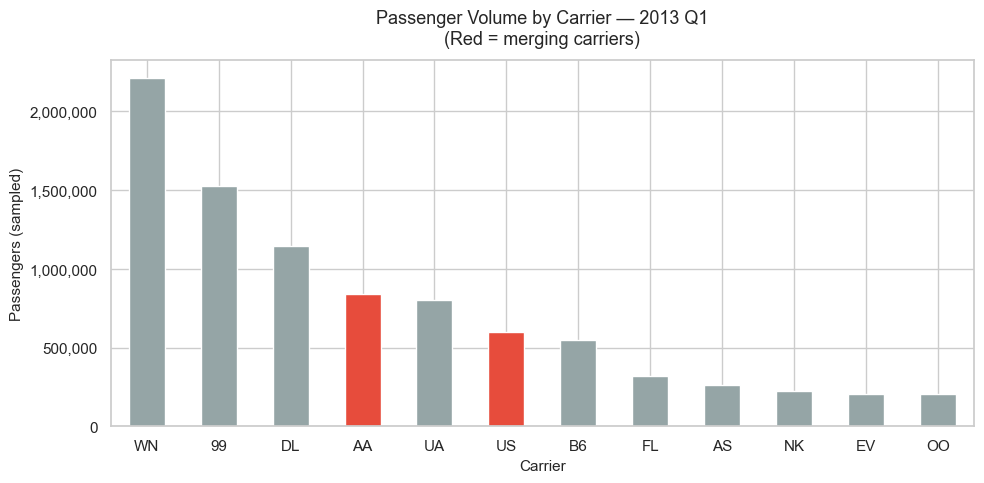

In [11]:
# Plot carrier market share by passengers
if carrier_col and 'Passengers' in df.columns:
    carrier_pax = (
        df.groupby(carrier_col)['Passengers']
        .sum()
        .sort_values(ascending=False)
        .head(12)
    )

    colors = ['#e74c3c' if c in ['AA', 'US'] else '#95a5a6' for c in carrier_pax.index]

    fig, ax = plt.subplots()
    carrier_pax.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
    ax.set_title(f'Passenger Volume by Carrier — {YEAR} Q{QUARTER}\n(Red = merging carriers)', 
                 fontsize=13, pad=12)
    ax.set_xlabel('Carrier', fontsize=11)
    ax.set_ylabel('Passengers (sampled)', fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.set_xticklabels(carrier_pax.index, rotation=0)
    plt.tight_layout()
    plt.show()

---
## 4. Route-Level Analysis — Identifying Treated vs Control Routes

**Treated routes:** Those where both AA and US Airways operated pre-merger — these face the most direct competitive harm from consolidation.

**Control routes:** Those where only one of the two carriers operated — used as the counterfactual.

In [12]:
if carrier_col:
    # Identify origin/dest columns
    origin_col = 'Origin' if 'Origin' in df.columns else 'ORIGIN'
    dest_col = 'Dest' if 'Dest' in df.columns else 'DEST'

    aa_us = df[df[carrier_col].isin(['AA', 'US'])].copy()

    # Create directional route identifier
    aa_us['route'] = aa_us[origin_col] + '-' + aa_us[dest_col]

    aa_routes = set(aa_us[aa_us[carrier_col] == 'AA']['route'])
    us_routes = set(aa_us[aa_us[carrier_col] == 'US']['route'])

    treated_routes  = aa_routes & us_routes          # Both carriers
    aa_only_routes  = aa_routes - us_routes          # AA only
    us_only_routes  = us_routes - aa_routes          # US only
    control_routes  = aa_only_routes | us_only_routes

    print("Route classification:")
    print(f"  Treated (AA + US overlap): {len(treated_routes):>5,} routes")
    print(f"  AA only (control):         {len(aa_only_routes):>5,} routes")
    print(f"  US only (control):         {len(us_only_routes):>5,} routes")
    print(f"  Total control routes:      {len(control_routes):>5,} routes")
    print(f"\n  Treatment share: {len(treated_routes) / (len(treated_routes) + len(control_routes)):.1%} of all AA/US routes")

Route classification:
  Treated (AA + US overlap): 3,187 routes
  AA only (control):         3,867 routes
  US only (control):         3,871 routes
  Total control routes:      7,738 routes

  Treatment share: 29.2% of all AA/US routes


In [13]:
# Preview some treated routes
if carrier_col:
    print("Sample treated routes (both AA and US flew here):")
    sample = sorted(list(treated_routes))[:20]
    for i, route in enumerate(sample):
        print(f"  {route}")

Sample treated routes (both AA and US flew here):
  ABQ-ATL
  ABQ-BOS
  ABQ-BWI
  ABQ-CLT
  ABQ-DCA
  ABQ-DFW
  ABQ-DTW
  ABQ-EWR
  ABQ-FAT
  ABQ-FLL
  ABQ-HNL
  ABQ-IAH
  ABQ-IND
  ABQ-JFK
  ABQ-LAX
  ABQ-LGA
  ABQ-MCO
  ABQ-MSP
  ABQ-OGG
  ABQ-ORD


---
## 5. Fare Analysis

Compare fares between treated and control routes, and between AA and US Airways.

In [14]:
if carrier_col and 'MktFare' in df.columns:
    aa_us['treatment'] = aa_us['route'].apply(
        lambda r: 'Treated (AA+US overlap)' if r in treated_routes else 'Control (one carrier)'
    )

    # Filter out extreme fares (data quality)
    fare_df = aa_us[(aa_us['MktFare'] > 20) & (aa_us['MktFare'] < 2000)]

    print("Average fare by treatment status:")
    print(fare_df.groupby('treatment')['MktFare'].agg(['mean', 'median', 'count']).round(2))

Average fare by treatment status:
                           mean  median   count
treatment                                      
Control (one carrier)    251.84   218.0  156514
Treated (AA+US overlap)  288.65   240.0  523965


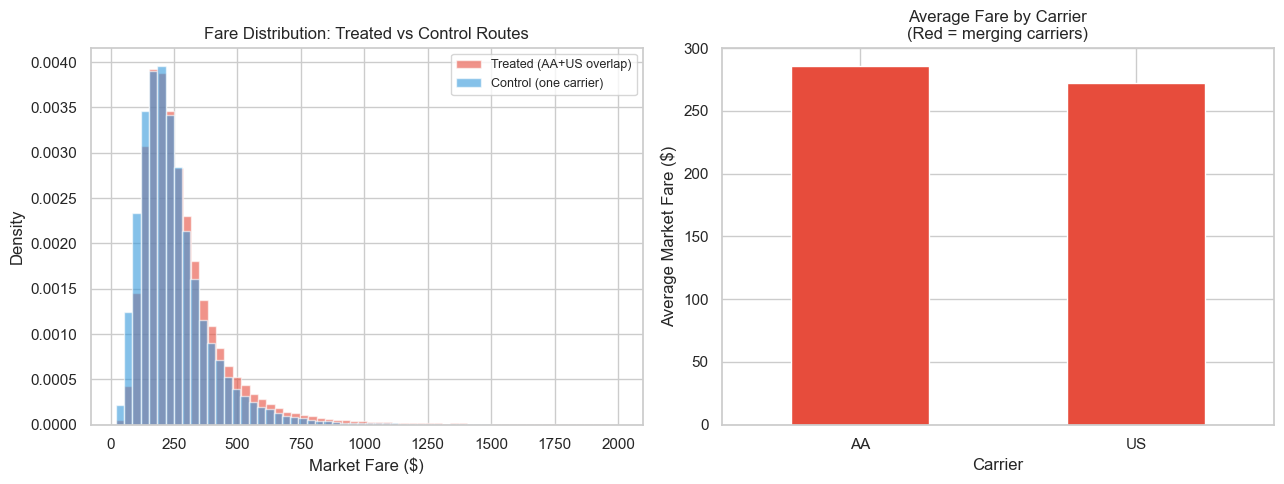

In [15]:
# Fare distribution plot — treated vs control
if carrier_col and 'MktFare' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Left: histogram by treatment
    for group, color in zip(['Treated (AA+US overlap)', 'Control (one carrier)'],
                             ['#e74c3c', '#3498db']):
        subset = fare_df[fare_df['treatment'] == group]['MktFare']
        axes[0].hist(subset, bins=60, alpha=0.6, color=color, label=group, density=True)
    axes[0].set_title('Fare Distribution: Treated vs Control Routes', fontsize=12)
    axes[0].set_xlabel('Market Fare ($)')
    axes[0].set_ylabel('Density')
    axes[0].legend(fontsize=9)

    # Right: average fare by carrier
    carrier_fares = (
        fare_df.groupby(carrier_col)['MktFare']
        .mean()
        .sort_values(ascending=False)
        .head(10)
    )
    colors_bar = ['#e74c3c' if c in ['AA', 'US'] else '#95a5a6' for c in carrier_fares.index]
    carrier_fares.plot(kind='bar', ax=axes[1], color=colors_bar, edgecolor='white')
    axes[1].set_title('Average Fare by Carrier\n(Red = merging carriers)', fontsize=12)
    axes[1].set_xlabel('Carrier')
    axes[1].set_ylabel('Average Market Fare ($)')
    axes[1].set_xticklabels(carrier_fares.index, rotation=0)

    plt.tight_layout()
    plt.show()

---
## 6. Top Treated Routes by Passenger Volume

These are the highest-traffic routes where both AA and US competed — likely to show the largest damages if prices rose post-merger.

In [16]:
if carrier_col and 'Passengers' in df.columns and 'MktFare' in df.columns:
    treated_summary = (
        fare_df[fare_df['treatment'] == 'Treated (AA+US overlap)']
        .groupby('route')
        .agg(
            avg_fare=('MktFare', 'mean'),
            total_passengers=('Passengers', 'sum'),
            num_obs=('MktFare', 'count')
        )
        .sort_values('total_passengers', ascending=False)
        .reset_index()
    )

    print(f"Top 15 treated routes by passenger volume ({YEAR} Q{QUARTER}):")
    print(treated_summary.head(15).to_string(index=False))

Top 15 treated routes by passenger volume (2013 Q1):
  route   avg_fare  total_passengers  num_obs
ORD-LGA 241.517014            9743.0     2083
LGA-ORD 250.806098            9481.0     1935
MIA-LGA 267.492749            8901.0     2725
LGA-MIA 259.042796            8835.0     2622
LAX-JFK 453.100870            7655.0     2990
JFK-LAX 451.108417            7440.0     2899
MCO-PHL 232.110834            7352.0     1271
PHL-MCO 231.912539            7343.0     1292
DFW-ORD 279.438255            6782.0     1759
ORD-DFW 276.404775            6735.0     1709
DFW-LAX 310.779754            5860.0     1872
LAS-DFW 313.423110            5795.0     1225
LAX-DFW 323.238869            5693.0     1751
DFW-LAS 290.292916            5630.0     1183
PHX-ORD 283.876476            5596.0     1893


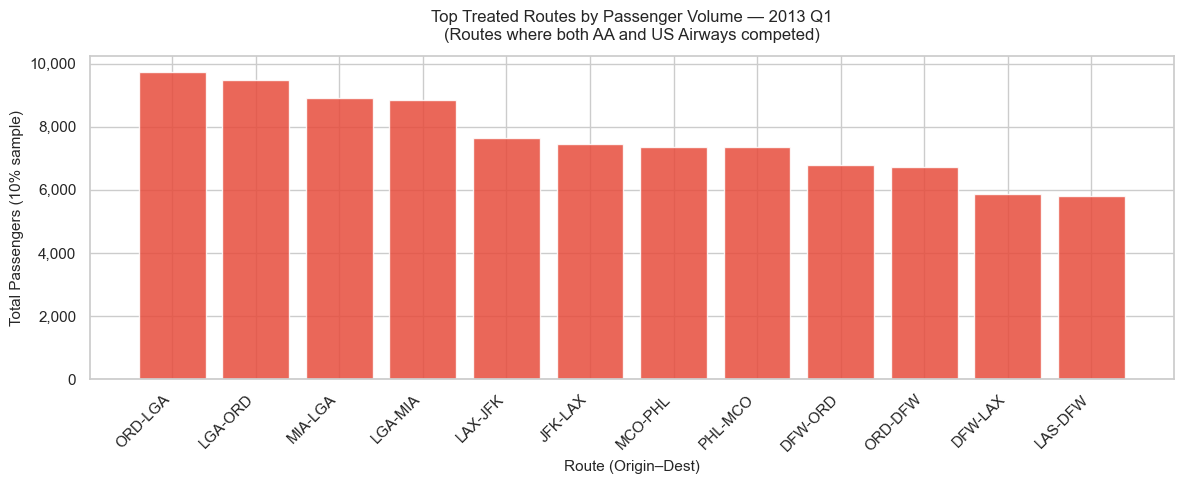

In [17]:
# Bar chart of top treated routes
if carrier_col and 'Passengers' in df.columns:
    top_routes = treated_summary.head(12)

    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(top_routes['route'], top_routes['total_passengers'],
                  color='#e74c3c', edgecolor='white', alpha=0.85)
    ax.set_title(f'Top Treated Routes by Passenger Volume — {YEAR} Q{QUARTER}\n'
                 '(Routes where both AA and US Airways competed)',
                 fontsize=12, pad=12)
    ax.set_xlabel('Route (Origin–Dest)', fontsize=11)
    ax.set_ylabel('Total Passengers (10% sample)', fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

---
## 7. Distance Distribution

Route distance (`MktMilesFlown`) will be an important control variable and heterogeneity dimension in the causal forest — longer routes may have different competitive dynamics.

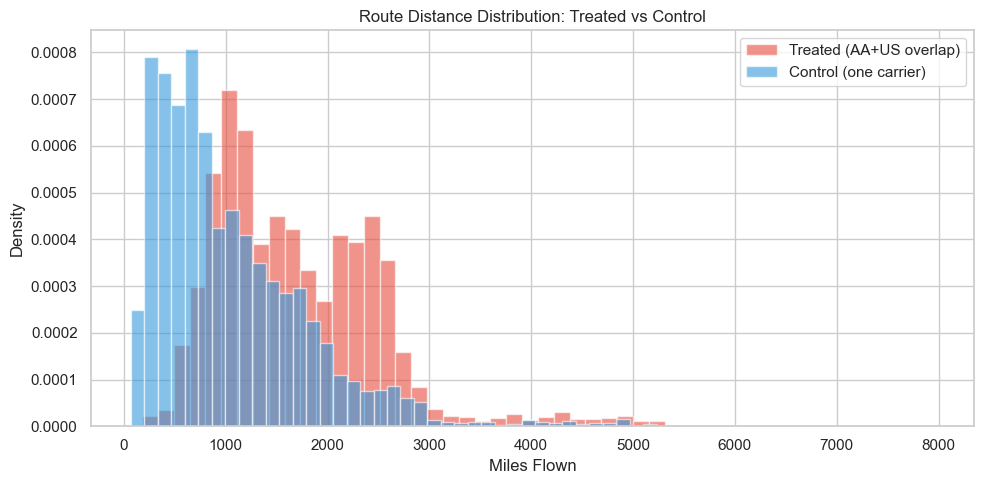

Distance summary by treatment status:
                            count    mean    std    min     25%     50%  \
treatment                                                                 
Control (one carrier)    156514.0  1047.2  764.5   68.0   484.0   848.0   
Treated (AA+US overlap)  523965.0  1708.4  820.2  178.0  1085.0  1562.0   

                            75%     max  
treatment                                
Control (one carrier)    1435.0  6688.0  
Treated (AA+US overlap)  2257.0  7954.0  


In [18]:
dist_col = 'MktMilesFlown' if 'MktMilesFlown' in df.columns else None

if dist_col and carrier_col:
    fig, ax = plt.subplots()

    for group, color in zip(['Treated (AA+US overlap)', 'Control (one carrier)'],
                             ['#e74c3c', '#3498db']):
        if 'treatment' in fare_df.columns:
            subset = fare_df[fare_df['treatment'] == group][dist_col].dropna()
            ax.hist(subset, bins=50, alpha=0.6, color=color, label=group, density=True)

    ax.set_title('Route Distance Distribution: Treated vs Control', fontsize=12)
    ax.set_xlabel('Miles Flown')
    ax.set_ylabel('Density')
    ax.legend()
    plt.tight_layout()
    plt.show()

    print("Distance summary by treatment status:")
    print(fare_df.groupby('treatment')[dist_col].describe().round(1))

---
## 8. Validation Summary

Final checklist — everything you need to see green before proceeding with the full download.

In [19]:
print("=" * 55)
print(" DB1B DATA VALIDATION SUMMARY")
print("=" * 55)

checks = {}

# 1. Loaded successfully
checks['Data loaded'] = len(df) > 100_000

# 2. Reasonable row count
checks[f'Row count OK ({len(df):,} rows)'] = len(df) > 500_000

# 3. Carriers present
if carrier_col:
    checks['AA present'] = 'AA' in df[carrier_col].values
    checks['US Airways present'] = 'US' in df[carrier_col].values

# 4. Fare column exists
checks['MktFare column exists'] = 'MktFare' in df.columns

# 5. Fare range is reasonable
if 'MktFare' in df.columns:
    median_fare = df['MktFare'].median()
    checks[f'Fare range reasonable (median ${median_fare:.0f})'] = 100 < median_fare < 600

# 6. Treated routes found
if carrier_col:
    checks[f'Treated routes found ({len(treated_routes):,})'] = len(treated_routes) > 50

# 7. Control routes found
if carrier_col:
    checks[f'Control routes found ({len(control_routes):,})'] = len(control_routes) > 100

# Print results
all_pass = True
for check, passed in checks.items():
    icon = '✅' if passed else '❌'
    print(f"  {icon}  {check}")
    if not passed:
        all_pass = False

print("=" * 55)
if all_pass:
    print("  🎉 ALL CHECKS PASSED — safe to proceed with full download!")
else:
    print("  ⚠️  Some checks failed — review the output above.")
print("=" * 55)

 DB1B DATA VALIDATION SUMMARY
  ✅  Data loaded
  ✅  Row count OK (5,259,289 rows)
  ✅  AA present
  ✅  US Airways present
  ✅  MktFare column exists
  ✅  Fare range reasonable (median $214)
  ✅  Treated routes found (3,187)
  ✅  Control routes found (7,738)
  🎉 ALL CHECKS PASSED — safe to proceed with full download!


---
## 9. Save Data

Save as Parquet — much faster to read than CSV for large files.

In [ ]:
output_path = f"db1b_market_{YEAR}_Q{QUARTER}.parquet"
df.to_parquet(output_path, index=False)
print(f"✅ Saved to {output_path}")

# Quick reload test
df_reload = pd.read_parquet(output_path)
print(f"   Reload test: {len(df_reload):,} rows — ✅ OK")

---
## Next Steps

If all checks passed above, you're ready to download the full study period:

```python
# Full download loop — run this AFTER validation passes
import time
import os

os.makedirs('data/raw', exist_ok=True)

for year in range(2010, 2018):  # 2010–2017
    for quarter in range(1, 5): # Q1–Q4
        url = (
            f"https://transtats.bts.gov/PREZIP/"
            f"Origin_and_Destination_Survey_DB1BMarket_{year}_{quarter}.zip"
        )
        response = requests.get(url, timeout=180)
        with zipfile.ZipFile(io.BytesIO(response.content)) as z:
            with z.open(z.namelist()[0]) as f:
                pd.read_csv(f, low_memory=False).to_parquet(
                    f'data/raw/db1b_market_{year}_Q{quarter}.parquet', index=False
                )
        print(f'  ✅ {year} Q{quarter}')
        time.sleep(1)  # Be polite to the BTS server
```

**Estimated total size:** ~2–4 GB uncompressed across 32 quarters.

**Next notebook:** `02_eda.ipynb` — panel construction, parallel trends checks, and EDA visualizations.